<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# **Box Plots**


Estimated time needed: **45** minutes


In this lab, you will focus on the visualization of data. The dataset will be provided through an RDBMS, and you will need to use SQL queries to extract the required data.


## Objectives


In this lab you will perform the following:


-   Visualize the distribution of data.

-   Visualize the relationship between two features.

-   Visualize data composition and comparisons using box plots.


### Setup: Connecting to the Database


#### 1. Download the Database File


In [1]:
!wget https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/QR9YeprUYhOoLafzlLspAw/survey-results-public.sqlite

--2026-01-12 14:33:07--  https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/QR9YeprUYhOoLafzlLspAw/survey-results-public.sqlite
169.63.118.104ourses-data.s3.us.cloud-object-storage.appdomain.cloud (cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud)... 
Connecting to cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud (cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud)|169.63.118.104|:443... connected.
200 OKequest sent, awaiting response... 
Length: 211415040 (202M) [application/octet-stream]
Saving to: ‘survey-results-public.sqlite.1’

survey-results-publ 100%[===================>] 201.62M  60.8MB/s    in 3.3s    

2026-01-12 14:33:14 (60.8 MB/s) - ‘survey-results-public.sqlite.1’ saved [211415040/211415040]



#### 2. Connect to the Database


**Install the needed libraries**


In [2]:
!pip install pandas

In [3]:
!pip install matplotlib

## Demo: Basic SQL Queries


#### Demo 1: Count the Number of Rows in the Table


In [4]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt

# Connect to the SQLite database
conn = sqlite3.connect('survey-results-public.sqlite')


In [5]:
QUERY = "SELECT COUNT(*) FROM main"
df = pd.read_sql_query(QUERY, conn)
print(df)


   COUNT(*)
0     65437


#### Demo 2: List All Tables


In [6]:
QUERY = """
SELECT name as Table_Name 
FROM sqlite_master 
WHERE type = 'table'
"""
pd.read_sql_query(QUERY, conn)


,Table_Name
0,main


#### Demo 3: Group Data by Age


In [7]:
QUERY = """
SELECT Age, COUNT(*) as count 
FROM main 
GROUP BY Age 
ORDER BY Age
"""
df_age = pd.read_sql_query(QUERY, conn)
print(df_age)


                  Age  count
0     18-24 years old  14098
1     25-34 years old  23911
2     35-44 years old  14942
3     45-54 years old   6249
4     55-64 years old   2575
5   65 years or older    772
6   Prefer not to say    322
7  Under 18 years old   2568


## Visualizing Data


### Task 1: Visualizing the Distribution of Data


**1. Box Plot of `CompTotal` (Total Compensation)**


Use a box plot to analyze the distribution and outliers in total compensation.


In [8]:
QUERY = """
SELECT CompTotal
FROM main
WHERE CompTotal IS NOT NULL
"""
df_comp = pd.read_sql_query(QUERY, conn)

print(df_comp.describe())



           CompTotal
count   3.374000e+04
mean   2.963841e+145
std    5.444117e+147
min     0.000000e+00
25%     6.000000e+04
50%     1.100000e+05
75%     2.500000e+05
max    1.000000e+150


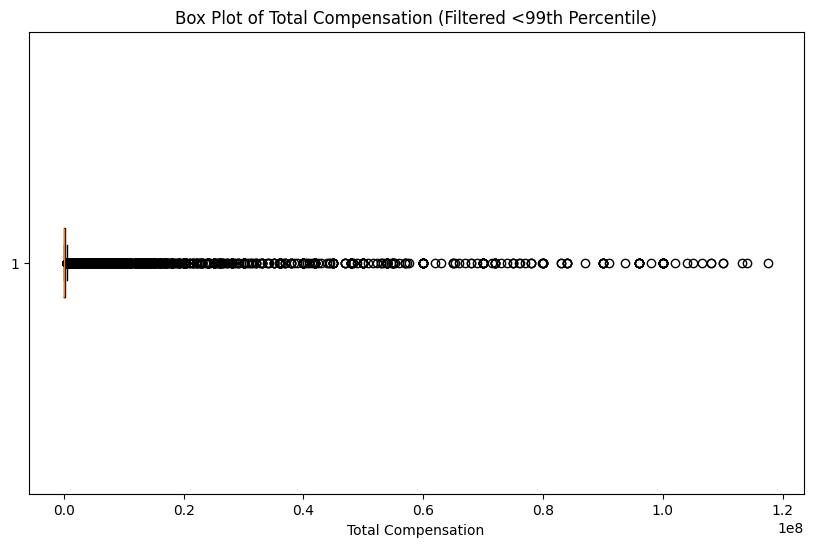

In [9]:
upper_limit = df_comp['CompTotal'].quantile(0.99)
df_filtered = df_comp[df_comp['CompTotal'] <= upper_limit]

plt.figure(figsize=(10,6))
plt.boxplot(df_filtered['CompTotal'], vert=False)
plt.title('Box Plot of Total Compensation (Filtered <99th Percentile)')
plt.xlabel('Total Compensation')
plt.show()


**2. Box Plot of Age (converted to numeric values)**


Convert the `Age` column into numerical values and visualize the distribution.


In [10]:
age_mapping = {
    'Under 18 years old': 15,
    '18-24 years old': 21,
    '25-34 years old': 30,
    '35-44 years old': 40,
    '45-54 years old': 50,
    '55-64 years old': 60,
    '65 years or older': 70
}

df_age['Age_numeric'] = df_age['Age'].map(age_mapping)

# Remove rows like "Prefer not to say"
df_age = df_age.dropna()


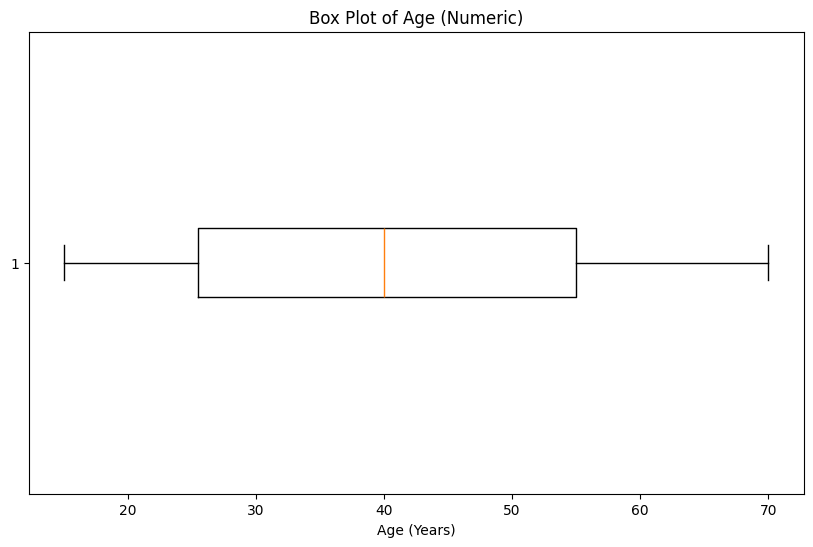

In [11]:
plt.figure(figsize=(10,6))
plt.boxplot(df_age['Age_numeric'], vert=False)
plt.title('Box Plot of Age (Numeric)')
plt.xlabel('Age (Years)')
plt.show()


### Task 2: Visualizing Relationships in Data


**1. Box Plot of `CompTotal` Grouped by Age Groups:**


Visualize the distribution of compensation across different age groups.


In [12]:
QUERY = """
SELECT Age, CompTotal
FROM main
WHERE Age IS NOT NULL
  AND CompTotal IS NOT NULL
"""
df_age_comp = pd.read_sql_query(QUERY, conn)

df_age_comp.head()


,Age,CompTotal
0,18-24 years old,2040000.0
1,25-34 years old,28000.0
2,35-44 years old,85000.0
3,35-44 years old,50000.0
4,25-34 years old,110000.0


In [13]:
age_order = [
    'Under 18 years old',
    '18-24 years old',
    '25-34 years old',
    '35-44 years old',
    '45-54 years old',
    '55-64 years old',
    '65 years or older'
]

df_age_comp['Age'] = pd.Categorical(
    df_age_comp['Age'],
    categories=age_order,
    ordered=True
)


<Figure size 1200x600 with 0 Axes>

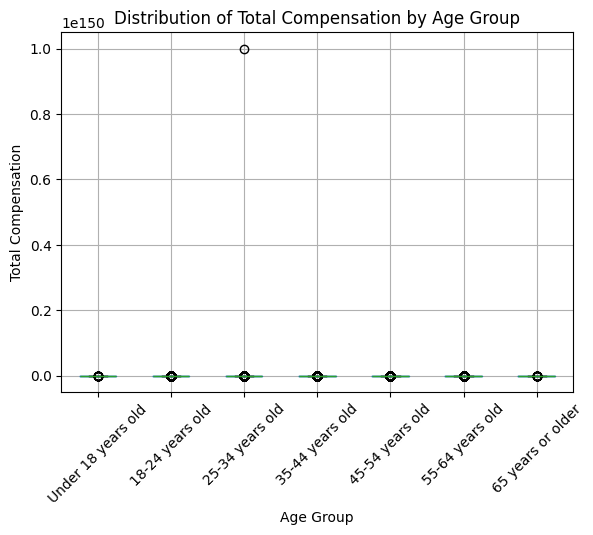

In [14]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
df_age_comp.boxplot(
    column='CompTotal',
    by='Age',
    rot=45
)

plt.title('Distribution of Total Compensation by Age Group')
plt.suptitle('')  # removes automatic pandas subtitle
plt.xlabel('Age Group')
plt.ylabel('Total Compensation')
plt.show()


**2. Box Plot of `CompTotal` Grouped by Job Satisfaction (`JobSatPoints_6`):**


Examine how compensation varies based on job satisfaction levels.


In [15]:
QUERY = """
SELECT JobSatPoints_6, CompTotal
FROM main
WHERE JobSatPoints_6 IS NOT NULL
  AND CompTotal IS NOT NULL
"""
df_jobsat = pd.read_sql_query(QUERY, conn)

df_jobsat.head()


,JobSatPoints_6,CompTotal
0,65.0,2040000.0
1,0.0,85000.0
2,20.0,110000.0
3,30.0,126420.0
4,30.0,195000.0


<Figure size 1200x600 with 0 Axes>

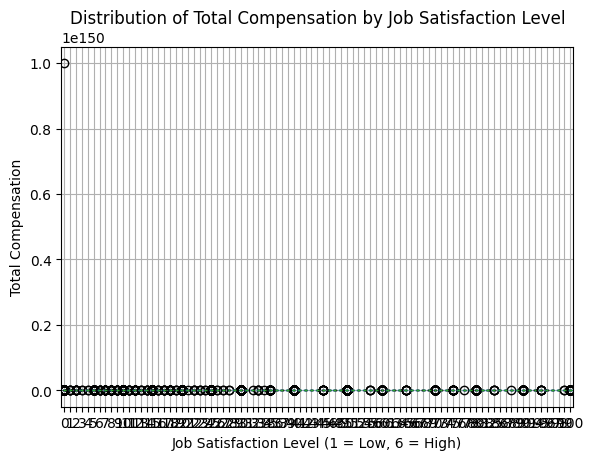

In [16]:
import matplotlib.pyplot as plt


df_jobsat['JobSatPoints_6'] = df_jobsat['JobSatPoints_6'].astype(int)

plt.figure(figsize=(12,6))

df_jobsat.boxplot(
    column='CompTotal',
    by='JobSatPoints_6'
)

plt.title('Distribution of Total Compensation by Job Satisfaction Level')
plt.suptitle('')  # Remove default pandas subtitle
plt.xlabel('Job Satisfaction Level (1 = Low, 6 = High)')
plt.ylabel('Total Compensation')
plt.show()


### Task 3: Visualizing the Composition of Data


**1. Box Plot of `ConvertedCompYearly` for the Top 5 Developer Types:**


Analyze compensation across the top 5 developer roles.


Top 5 Developer Roles: ['Developer, full-stack', 'Developer, back-end', 'Student', 'Developer, front-end', 'Developer, desktop or enterprise applications']


<Figure size 1400x600 with 0 Axes>

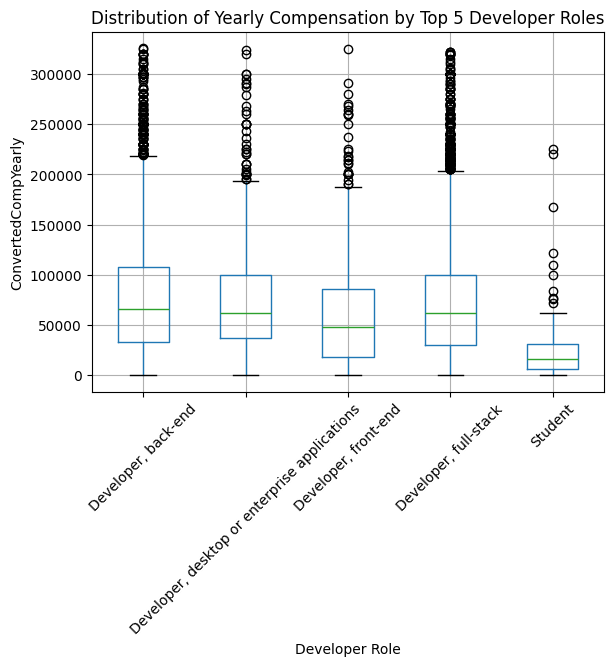

In [17]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter

# -----------------------------
# Connect to SQLite database
# -----------------------------
conn = sqlite3.connect('survey-results-public.sqlite')

# -----------------------------
# Step 1: Identify Top 5 Developer Types
# -----------------------------
QUERY = """
SELECT DevType
FROM main
WHERE DevType IS NOT NULL
"""
df_dev = pd.read_sql_query(QUERY, conn)

dev_counter = Counter()

for roles in df_dev['DevType']:
    for role in roles.split(';'):
        dev_counter[role.strip()] += 1

top_5_roles = [role for role, _ in dev_counter.most_common(5)]
print("Top 5 Developer Roles:", top_5_roles)

# -----------------------------
# Step 2: Load Compensation Data
# -----------------------------
QUERY = """
SELECT DevType, ConvertedCompYearly
FROM main
WHERE DevType IS NOT NULL
  AND ConvertedCompYearly IS NOT NULL
"""
df_comp = pd.read_sql_query(QUERY, conn)

# -----------------------------
# Step 3: Expand Roles into Rows
# -----------------------------
rows = []

for _, row in df_comp.iterrows():
    for role in row['DevType'].split(';'):
        role = role.strip()
        if role in top_5_roles:
            rows.append({
                'DevType': role,
                'ConvertedCompYearly': row['ConvertedCompYearly']
            })

df_plot = pd.DataFrame(rows)

# -----------------------------
# Step 4: Remove Extreme Outliers (Optional but Recommended)
# -----------------------------
upper_limit = df_plot['ConvertedCompYearly'].quantile(0.99)
df_plot = df_plot[df_plot['ConvertedCompYearly'] <= upper_limit]

# -----------------------------
# Step 5: Box Plot
# -----------------------------
plt.figure(figsize=(14,6))
df_plot.boxplot(
    column='ConvertedCompYearly',
    by='DevType',
    rot=45
)

plt.title('Distribution of Yearly Compensation by Top 5 Developer Roles')
plt.suptitle('')
plt.xlabel('Developer Role')
plt.ylabel('ConvertedCompYearly')
plt.show()


**2. Box Plot of `CompTotal` for the Top 5 Countries:**


Analyze compensation across respondents from the top 5 countries.


Top 5 Countries: ['United States of America', 'Germany', 'India', 'United Kingdom of Great Britain and Northern Ireland', 'Ukraine']


<Figure size 1400x600 with 0 Axes>

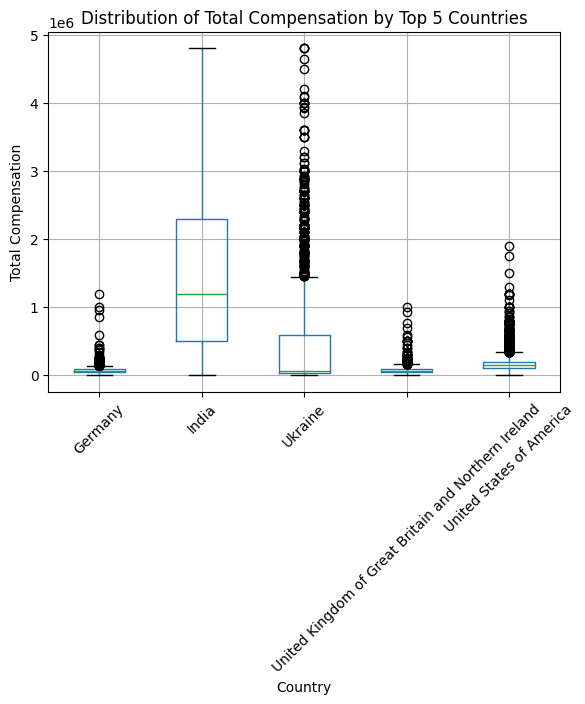

In [18]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt

# -----------------------------
# Connect to SQLite database
# -----------------------------
conn = sqlite3.connect('survey-results-public.sqlite')

# -----------------------------
# Step 1: Identify Top 5 Countries
# -----------------------------
QUERY = """
SELECT Country
FROM main
WHERE Country IS NOT NULL
"""
df_country = pd.read_sql_query(QUERY, conn)

top_5_countries = df_country['Country'].value_counts().head(5).index.tolist()
print("Top 5 Countries:", top_5_countries)

# -----------------------------
# Step 2: Load Compensation Data
# -----------------------------
QUERY = """
SELECT Country, CompTotal
FROM main
WHERE Country IS NOT NULL
  AND CompTotal IS NOT NULL
"""
df_comp = pd.read_sql_query(QUERY, conn)

# -----------------------------
# Step 3: Filter Top 5 Countries
# -----------------------------
df_top5 = df_comp[df_comp['Country'].isin(top_5_countries)]

# -----------------------------
# Step 4: Remove Extreme Outliers (Optional but Recommended)
# -----------------------------
upper_limit = df_top5['CompTotal'].quantile(0.99)
df_top5 = df_top5[df_top5['CompTotal'] <= upper_limit]

# -----------------------------
# Step 5: Box Plot
# -----------------------------
plt.figure(figsize=(14,6))
df_top5.boxplot(
    column='CompTotal',
    by='Country',
    rot=45
)

plt.title('Distribution of Total Compensation by Top 5 Countries')
plt.suptitle('')
plt.xlabel('Country')
plt.ylabel('Total Compensation')
plt.show()


### Task 4: Visualizing Comparison of Data


**1. Box Plot of CompTotal Across Employment Types:**


Analyze compensation for different employment types.


<Figure size 1200x600 with 0 Axes>

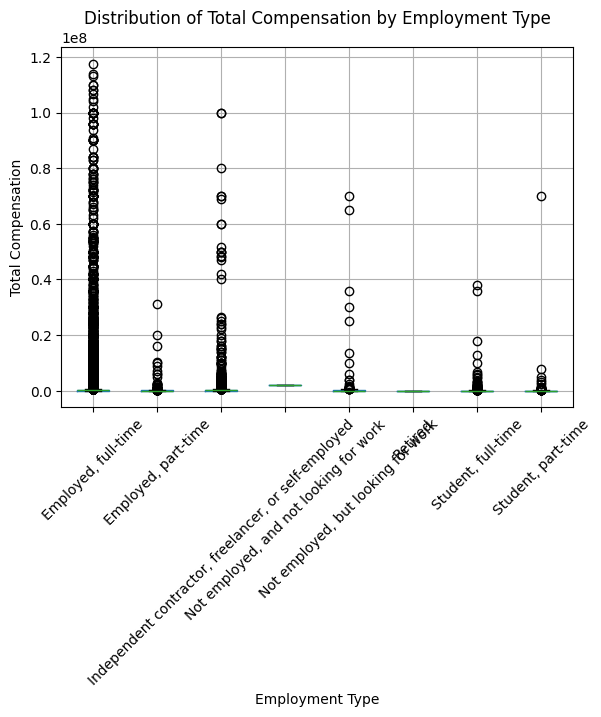

In [19]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt

# -----------------------------
# Connect to SQLite database
# -----------------------------
conn = sqlite3.connect('survey-results-public.sqlite')

# -----------------------------
# Step 1: Load Employment Type & Compensation
# -----------------------------
QUERY = """
SELECT Employment, CompTotal
FROM main
WHERE Employment IS NOT NULL
  AND CompTotal IS NOT NULL
"""
df_emp = pd.read_sql_query(QUERY, conn)

# -----------------------------
# Step 2: Clean Employment Column
# (Some respondents have multiple employment types)
# -----------------------------
df_emp['Employment'] = df_emp['Employment'].apply(lambda x: x.split(';')[0])

# -----------------------------
# Step 3: Remove Extreme Outliers (Optional)
# -----------------------------
upper_limit = df_emp['CompTotal'].quantile(0.99)
df_emp = df_emp[df_emp['CompTotal'] <= upper_limit]

# -----------------------------
# Step 4: Box Plot
# -----------------------------
plt.figure(figsize=(12,6))
df_emp.boxplot(
    column='CompTotal',
    by='Employment',
    rot=45
)

plt.title('Distribution of Total Compensation by Employment Type')
plt.suptitle('')
plt.xlabel('Employment Type')
plt.ylabel('Total Compensation')
plt.show()


**2. Box Plot of `YearsCodePro` by Job Satisfaction (`JobSatPoints_6`):**


Examine the distribution of professional coding years by job satisfaction levels.


<Figure size 1200x600 with 0 Axes>

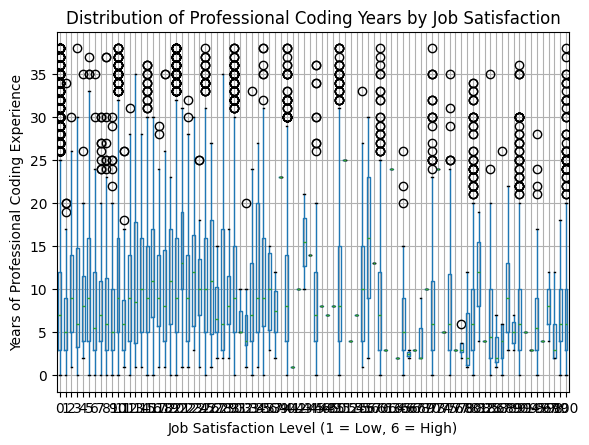

In [20]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt

# -----------------------------
# Connect to SQLite database
# -----------------------------
conn = sqlite3.connect('survey-results-public.sqlite')

# -----------------------------
# Step 1: Load Job Satisfaction & YearsCodePro
# -----------------------------
QUERY = """
SELECT JobSatPoints_6, YearsCodePro
FROM main
WHERE JobSatPoints_6 IS NOT NULL
  AND YearsCodePro IS NOT NULL
"""
df = pd.read_sql_query(QUERY, conn)

# -----------------------------
# Step 2: Convert YearsCodePro to Numeric
# (Handle values like 'Less than 1 year' and 'More than 50 years')
# -----------------------------
df['YearsCodePro'] = df['YearsCodePro'].replace({
    'Less than 1 year': 0,
    'More than 50 years': 50
})

df['YearsCodePro'] = pd.to_numeric(df['YearsCodePro'], errors='coerce')
df = df.dropna()

# -----------------------------
# Step 3: Ensure Job Satisfaction is Numeric
# -----------------------------
df['JobSatPoints_6'] = df['JobSatPoints_6'].astype(int)

# -----------------------------
# Step 4: Remove Extreme Outliers (Optional)
# -----------------------------
upper_limit = df['YearsCodePro'].quantile(0.99)
df = df[df['YearsCodePro'] <= upper_limit]

# -----------------------------
# Step 5: Box Plot
# -----------------------------
plt.figure(figsize=(12,6))
df.boxplot(
    column='YearsCodePro',
    by='JobSatPoints_6'
)

plt.title('Distribution of Professional Coding Years by Job Satisfaction')
plt.suptitle('')
plt.xlabel('Job Satisfaction Level (1 = Low, 6 = High)')
plt.ylabel('Years of Professional Coding Experience')
plt.show()


### Final Step: Close the Database Connection


After completing the lab, close the connection to the SQLite database:


In [42]:
conn.close()

## Summary


In this lab, you used box plots to visualize various aspects of the dataset, focusing on:

- Visualize distributions of compensation and age.

- Explore relationships between compensation, job satisfaction, and professional coding experience.

- Analyze data composition across developer roles and countries.

- Compare compensation across employment types and satisfaction levels.

Box plots provided clear insights into the spread, outliers, and central tendencies of various features in the dataset.


## Authors:
Ayushi Jain


### Other Contributors:
- Rav Ahuja
- Lakshmi Holla
- Malika


<!--## Change Log
|Date (YYYY-MM-DD)|Version|Changed By|Change Description|
|-|-|-|-|               
|2024-10-07|1.2|Madhusudan Moole|Reviewed and updated lab|                                                                                      
|2024-10-06|1.0|Raghul Ramesh|Created lab|-->


Copyright © IBM Corporation. All rights reserved.
